# Deploy a iGCR-2 circuit onto IBM-Q for sampling

In [2]:
import functools
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyscf.cc
import pyscf.gto
import pyscf.mcscf
import pyscf.scf
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from xquces.gcr import IGCR2SpinRestrictedParameterization
from xquces.qiskit import generate_gcr2_pass_manager
from xquces.qiskit.gates import igcr2_stateprep_jw_circuit

# N2/cc-pVDZ at equilibrium, with N 1s frozen.

In [3]:
BASIS = "cc-pvdz"
N_FROZEN = 2
TARGET_R = 1.95
R_GRID = np.arange(0.9, TARGET_R+0.1, 0.05)
BACKEND_NAME = "ibm_fez"
N_REPS = 1
SEED = 7
OPTIMIZATION_LEVEL = 3
SHOTS = 100_000
SUBMIT_JOB = True
TWO_QUBIT_ERROR_THRESHOLD = 1.0
READOUT_ERROR_THRESHOLD = 1.0
OUTPUT_DIR = Path("results/n2_ccpvdz_frozen_core_fez")

TWO_QUBIT_EXCLUDED_OPS = {"barrier", "delay", "measure", "reset"}


- Here we run CCSD with continuation of parameters to get a smooth initial guess for iGCR-2. This is especially useful around dissociation where CCSD breaks down.

In [4]:
pyscf.lib.num_threads(1)
records = []
prev_dm = None
prev_t1 = None
prev_t2 = None
target_data = None

for R in R_GRID:
    print(f"R = {R:.2f}")

    mol = pyscf.gto.Mole()
    mol.build(
        atom=[["N", (0.0, 0.0, 0.0)], ["N", (float(R), 0.0, 0.0)]],
        basis=BASIS,
        symmetry="Dooh",
        verbose=0,
    )
    mf = pyscf.scf.RHF(mol)

    if prev_dm is None:
        mf.kernel()
    else:
        mf.kernel(dm0=prev_dm)

    if not mf.converged:
        raise RuntimeError(f"RHF failed at R={R}")

    nmo = mf.mo_coeff.shape[1]
    active_space = list(range(N_FROZEN, nmo))
    norb = len(active_space)
    nelecas = int(round(np.sum(mf.mo_occ[active_space])))
    nelec = (nelecas // 2, nelecas // 2)

    cas = pyscf.mcscf.CASCI(mf, norb, nelec)
    mo = cas.sort_mo(active_space, base=0)
    h1, core_energy = cas.get_h1cas(mo)

    frozen = [i for i in range(nmo) if i not in active_space]
    cc = pyscf.cc.CCSD(mf, frozen=frozen)
    cc.conv_tol = 1e-10
    cc.conv_tol_normt = 1e-8
    cc.max_cycle = 200

    if prev_t1 is None:
        e_corr, t1, t2 = cc.kernel()
    else:
        e_corr, t1, t2 = cc.kernel(t1=prev_t1, t2=prev_t2)

    if not cc.converged:
        raise RuntimeError(f"CCSD failed at R={R}")

    t1_norm = float(np.linalg.norm(t1))
    t2_norm = float(np.linalg.norm(t2))
    t1_step = np.nan if prev_t1 is None else float(np.linalg.norm(t1 - prev_t1))
    t2_step = np.nan if prev_t2 is None else float(np.linalg.norm(t2 - prev_t2))

    records.append(
        {
            "R": float(R),
            "E_HF": float(mf.e_tot),
            "E_CCSD": float(cc.e_tot),
            "E_corr": float(e_corr),
            "t1_norm": t1_norm,
            "t2_norm": t2_norm,
            "t1_step": t1_step,
            "t2_step": t2_step,
            "ccsd_converged": bool(cc.converged),
            "norb": int(norb),
            "nelec": nelec,
        }
    )

    if abs(float(R) - TARGET_R) < 1e-8:
        target_data = {
            "R": float(R),
            "mol": mol,
            "mf": mf,
            "cc": cc,
            "norb": int(norb),
            "nelec": nelec,
            "active_space": active_space,
            "core_energy": float(core_energy),
            "h1": np.asarray(h1),
            "t1": np.asarray(t1),
            "t2": np.asarray(t2),
        }

    prev_dm = mf.make_rdm1()
    prev_t1 = np.asarray(t1)
    prev_t2 = np.asarray(t2)

if target_data is None:
    raise RuntimeError(f"TARGET_R={TARGET_R} was not present in R_GRID={R_GRID}.")

data = target_data
ccsd_df = pd.DataFrame(records)
ccsd_df


R = 0.90
R = 0.95
R = 1.00
R = 1.05
R = 1.10
R = 1.15
R = 1.20
R = 1.25
R = 1.30
R = 1.35
R = 1.40
R = 1.45
R = 1.50
R = 1.55
R = 1.60
R = 1.65
R = 1.70
R = 1.75
R = 1.80
R = 1.85
R = 1.90
R = 1.95
R = 2.00


,R,E_HF,E_CCSD,E_corr,t1_norm,t2_norm,t1_step,t2_step,ccsd_converged,norb,nelec
0,0.90,-108.782799,-109.050061,-0.267262,0.020800,0.259811,NaN,NaN,True,26,"(5, 5)"
1,0.95,-108.876887,-109.154376,-0.277488,0.024480,0.270923,0.031176,0.317585,True,26,"(5, 5)"
2,1.00,-108.929838,-109.217788,-0.287950,0.028486,0.282796,0.004645,0.024623,True,26,"(5, 5)"
3,1.05,-108.952704,-109.251405,-0.298701,0.032755,0.295495,0.041694,0.360585,True,26,"(5, 5)"
4,1.10,-108.953796,-109.263577,-0.309781,0.037237,0.309085,0.005109,0.026667,True,26,"(5, 5)"
5,1.15,-108.939356,-109.260570,-0.321214,0.041892,0.323633,0.005325,0.028261,True,26,"(5, 5)"
6,1.20,-108.914052,-109.247058,-0.333006,0.046682,0.339212,0.033118,0.269533,True,26,"(5, 5)"
7,1.25,-108.881366,-109.226514,-0.345148,0.051569,0.355907,0.019373,0.177854,True,26,"(5, 5)"
8,1.30,-108.843888,-109.201509,-0.357621,0.056514,0.373821,0.005865,0.035001,True,26,"(5, 5)"
9,1.35,-108.803534,-109.173935,-0.370400,0.061479,0.393087,0.073006,0.208585,True,26,"(5, 5)"


# Construct the circuit and transpile to heavy-hex IBM Fez backend

In [ ]:
data = target_data
norb = data["norb"]
nelec = data["nelec"]
nocc = nelec[0]

# Heavy-hex-friendly GCR2 layout

pairs_aa = [(p, p + 1) for p in range(norb - 1)] # same-spin follows a chain
pairs_ab = [(p, p) for p in range(norb) if p % 4 == 0] # mixed-spin are connected every 4-th rung of the heavy-hex ladder
interaction_pairs = (pairs_aa, pairs_ab)

igcr2_param = IGCR2SpinRestrictedParameterization(
    norb=norb,
    nocc=nocc,
    layers=N_REPS,
    interaction_pairs=pairs_aa,
)
igcr2_params = igcr2_param.parameters_from_ucj_t_amplitudes(
    data["t2"],
    t1=data["t1"],
    interaction_pairs=pairs_aa,
)
igcr2_ansatz = igcr2_param.ansatz_from_parameters(igcr2_params)

gcr2_circuit = igcr2_stateprep_jw_circuit(
    igcr2_ansatz,
    validate_orbital_rotations=True,
    sparsify_diagonal=True,
    sparsify_atol=1e-12,
)
gcr2_circuit.name = f"n2_igcr2_r{data['R']:.2f}"
raw_circuit = gcr2_circuit.decompose(reps=10)

# Qiskit depth accepts a CircuitInstruction filter; use it for the 2q layer count.
raw_two_qubit_depth = int(
    raw_circuit.depth(
        filter_function=lambda instruction: (
            len(instruction.qubits) == 2
            and instruction.operation.name not in TWO_QUBIT_EXCLUDED_OPS
        )
    )
)
raw_two_qubit_gates = sum(
    1
    for instruction in raw_circuit.data
    if len(instruction.qubits) == 2
    and instruction.operation.name not in TWO_QUBIT_EXCLUDED_OPS
)
raw_active_qubit_indices = set()
for instruction in raw_circuit.data:
    if instruction.operation.name in {"barrier", "delay"}:
        continue
    raw_active_qubit_indices.update(
        raw_circuit.find_bit(qubit).index for qubit in instruction.qubits
    )

raw_stats = {
    "circuit": "logical decomposed",
    "num_qubits": int(raw_circuit.num_qubits),
    "active_qubits": int(len(raw_active_qubit_indices)),
    "depth": int(raw_circuit.depth()),
    "two_qubit_depth": raw_two_qubit_depth,
    "two_qubit_gates": int(raw_two_qubit_gates),
    "size": int(raw_circuit.size()),
    "ops": {str(gate): int(count) for gate, count in raw_circuit.count_ops().items()},
}

print(f"R = {data['R']}")
print(f"norb = {norb}")
print(f"nelec = {nelec}")
print(f"logical_qubits = {2 * norb}")
print(f"iGCR2 params = {igcr2_param.n_params}")
print(f"iGCR2 layers = {igcr2_param.layers}")
print(f"pairs_aa = {len(pairs_aa)}")
print(f"pairs_ab_requested = {pairs_ab}")
print(f"raw_depth = {raw_stats['depth']}")
print(f"raw_2q_depth = {raw_stats['two_qubit_depth']}")
print(f"raw_2q = {raw_stats['two_qubit_gates']}")

pd.DataFrame([raw_stats]).drop(columns=["ops"])


R = 1.950000000000001
norb = 26
nelec = (5, 5)
logical_qubits = 52
iGCR2 params = 885
iGCR2 layers = 1
pairs_aa = 25
pairs_ab_requested = [(0, 0), (4, 4), (8, 8), (12, 12), (16, 16), (20, 20), (24, 24)]
raw_depth = 525
raw_2q_depth = 110
raw_2q = 1784


,circuit,num_qubits,active_qubits,depth,two_qubit_depth,two_qubit_gates,size
0,logical decomposed,52,52,525,110,1784,15658


In [11]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

service = QiskitRuntimeService()
backend = service.backend(BACKEND_NAME)

print(f"backend = {BACKEND_NAME}")
print(f"backend qubits = {backend.num_qubits}")

pm_result = generate_gcr2_pass_manager(
    backend=backend,
    norb=norb,
    connectivity="heavy-hex",
    interaction_pairs=interaction_pairs,
    optimization_level=OPTIMIZATION_LEVEL,
    seed_transpiler=SEED,
    two_qubit_error_threshold=TWO_QUBIT_ERROR_THRESHOLD,
    readout_error_threshold=READOUT_ERROR_THRESHOLD,
)

measured_circuit = gcr2_circuit.copy()
measured_circuit.name = f"{gcr2_circuit.name}_measured"
measured_circuit.measure_all()

isa_circuit = pm_result.pass_manager.run(measured_circuit)
isa_circuit.name = f"{gcr2_circuit.name}_{BACKEND_NAME}_isa"

# Repeat the same resource accounting directly on the backend ISA circuit.
isa_two_qubit_depth = int(
    isa_circuit.depth(
        filter_function=lambda instruction: (
            len(instruction.qubits) == 2
            and instruction.operation.name not in TWO_QUBIT_EXCLUDED_OPS
        )
    )
)
isa_two_qubit_gates = sum(
    1
    for instruction in isa_circuit.data
    if len(instruction.qubits) == 2
    and instruction.operation.name not in TWO_QUBIT_EXCLUDED_OPS
)
isa_active_qubit_indices = set()
for instruction in isa_circuit.data:
    if instruction.operation.name in {"barrier", "delay"}:
        continue
    isa_active_qubit_indices.update(
        isa_circuit.find_bit(qubit).index for qubit in instruction.qubits
    )

isa_stats = {
    "circuit": f"{BACKEND_NAME} ISA",
    "num_qubits": int(isa_circuit.num_qubits),
    "active_qubits": int(len(isa_active_qubit_indices)),
    "depth": int(isa_circuit.depth()),
    "two_qubit_depth": isa_two_qubit_depth,
    "two_qubit_gates": int(isa_two_qubit_gates),
    "size": int(isa_circuit.size()),
    "ops": {str(gate): int(count) for gate, count in isa_circuit.count_ops().items()},
}

resources = {
    "backend": BACKEND_NAME,
    "backend_num_qubits": int(backend.num_qubits),
    "R": float(data["R"]),
    "basis": BASIS,
    "n_frozen": int(N_FROZEN),
    "norb": int(norb),
    "nelec": [int(value) for value in nelec],
    "logical_qubits": int(2 * norb),
    "iGCR2_params": int(igcr2_param.n_params),
    "iGCR2_layers": int(igcr2_param.layers),
    "optimization_level": int(OPTIMIZATION_LEVEL),
    "seed_transpiler": int(SEED),
    "requested_alpha_beta_pairs": [list(pair) for pair in pairs_ab],
    "layout_alpha_beta_pairs": [
        list(pair) for pair in pm_result.layout.allowed_alpha_beta_pairs
    ],
    "initial_layout": [int(qubit) for qubit in pm_result.layout.initial_layout],
    "raw": raw_stats,
    "isa": isa_stats,
}

resources_path = OUTPUT_DIR / "n2_igcr2_fez_resources.json"
resources_csv = OUTPUT_DIR / "n2_igcr2_fez_resources.csv"
with resources_path.open("w") as f:
    json.dump(resources, f, indent=2)

resources_df = pd.DataFrame([raw_stats, isa_stats])
resources_df.to_csv(resources_csv, index=False)

print(f"allowed alpha-beta pairs = {resources['layout_alpha_beta_pairs']}")
print(f"ISA depth = {isa_stats['depth']}")
print(f"ISA 2q depth = {isa_stats['two_qubit_depth']}")
print(f"ISA 2q gates = {isa_stats['two_qubit_gates']}")
print(f"wrote {resources_path}")
print(f"wrote {resources_csv}")

resources_df.drop(columns=["ops"])


qiskit_runtime_service.__init__:WARNING:2026-05-28 16:25:51,025: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: UnitaryClusterJastrow. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-28 16:25:51,026: Using instance: UnitaryClusterJastrow, plan: open


backend = ibm_fez
backend qubits = 156
allowed alpha-beta pairs = [[0, 0], [4, 4], [8, 8], [12, 12], [16, 16], [20, 20], [24, 24]]
ISA depth = 531
ISA 2q depth = 152
ISA 2q gates = 1857
wrote results/n2_ccpvdz_frozen_core_fez/n2_igcr2_fez_resources.json
wrote results/n2_ccpvdz_frozen_core_fez/n2_igcr2_fez_resources.csv


,circuit,num_qubits,active_qubits,depth,two_qubit_depth,two_qubit_gates,size
0,logical decomposed,52,52,525,110,1784,15658
1,ibm_fez ISA,156,56,531,152,1857,12527


wrote results/n2_ccpvdz_frozen_core_fez/n2_igcr2_fez_resources.png


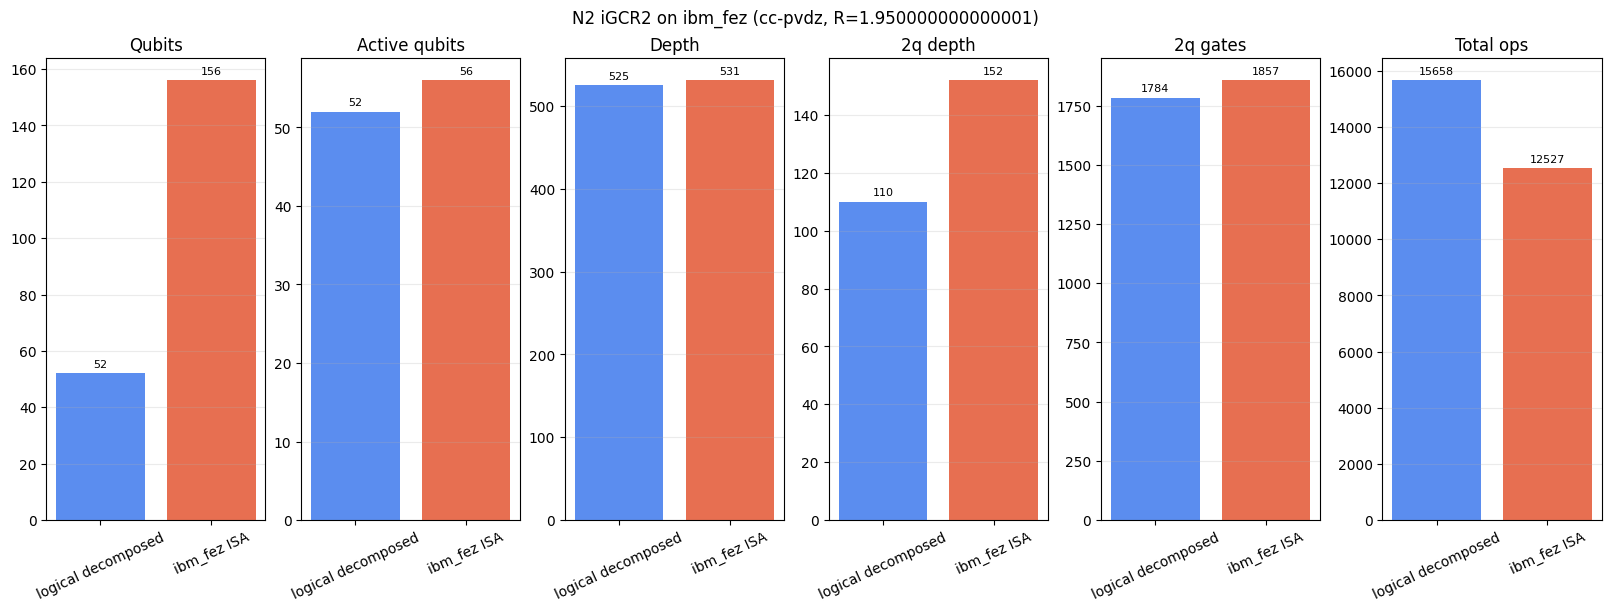

In [12]:
plot_metrics = {
    "num_qubits": "Qubits",
    "active_qubits": "Active qubits",
    "depth": "Depth",
    "two_qubit_depth": "2q depth",
    "two_qubit_gates": "2q gates",
    "size": "Total ops",
}

fig, axes = plt.subplots(
    1,
    len(plot_metrics),
    figsize=(16,6),
    constrained_layout=True,
)
colors = ["#5B8DEF", "#E76F51"]

for ax, (metric, title) in zip(axes, plot_metrics.items()):
    values = resources_df[metric].to_numpy(dtype=float)
    labels = resources_df["circuit"].to_list()
    bars = ax.bar(labels, values, color=colors[: len(values)])
    ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=8)
    ax.set_title(title)
    ax.tick_params(axis="x", labelrotation=25)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle(f"N2 iGCR2 on {BACKEND_NAME} ({BASIS}, R={data['R']})")
plot_path = OUTPUT_DIR / "n2_igcr2_fez_resources.png"
fig.savefig(plot_path, dpi=200)
print(f"wrote {plot_path}")
plt.show()


# Submit job

In [ ]:

sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=SHOTS)

print(f"submitted_job_id = {job.job_id()}")
print(f"backend = {BACKEND_NAME}")
print(f"shots = {SHOTS}")


submitted_job_id = d8c4rg38amns73bj0btg
backend = ibm_fez
shots = 100000
